In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
file_path = "../data/raw/PPR-ALL.csv"

if file_path.endswith(".csv"):
    df = pd.read_csv(file_path,
    encoding="cp1252",
    quotechar='"',
    low_memory=False
)
    
elif file_path.endswith(".json"):
    df = pd.read_json(file_path)
else:
    raise ValueError("Unsupported file format")

print("Data loaded successfully")



Data loaded successfully


In [12]:
df = df.rename(columns={
    "Date of Sale (dd/mm/yyyy)": "date",
    "Address": "address",
    "County": "county",
    "Eircode": "eircode",
    "Price (€)": "price",
    "Not Full Market Price": "not_full_market_price",
    "VAT Exclusive": "vat_exclusive",
    "Description of Property": "property_type",
    "Property Size Description": "property_size"
})


df["date"] = pd.to_datetime(df["date"],format="%d/%m/%Y",errors="coerce")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df["county"] = df["county"].str.strip().str.lower()

# Blank eircodes become proper missing values so dropna() catches them
df["eircode"] = df["eircode"].str.strip().replace("", np.nan)

df["price"] = pd.to_numeric(
    df["price"]
    .str.replace("€", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
# --- Outlier Handling (Percentile Trimming) ---
lower_percentile = df["price"].quantile(0.01)  # Bottom 1%
upper_percentile = df["price"].quantile(0.99)  # Top 1%

df = df[
    (df["not_full_market_price"].str.strip().str.title() == "No") &
    (df["price"] >= lower_percentile) &
    (df["price"] <= upper_percentile)
]

df = df.drop_duplicates()

In [13]:
print(f'Rows:     {len(df):,}')
print(f'Columns:  {df.shape[1]}')
print(f'Date range: {df["date"].min().date()} -> {df["date"].max().date()}')

labels = ['Min', '10th %ile', '25th %ile', 'Median', '75th %ile', '90th %ile', 'Max']
values = np.percentile(df['price'], [0, 10, 25, 50, 75, 90, 100])

print('National price distribution (all years):')
print('-' * 35)
for l, v in zip(labels, values):
    print(f'  {l} €{v:.0f}')
print(f'\n  Mean        €{df["price"].mean():.0f}')
print(f'  Std dev     €{df["price"].std():.0f}')

annual = df.groupby('year').agg(
median_price=('price', 'median'),
mean_price=('price', 'mean'),
total_sales=('price', 'count'),
total_value=('price', 'sum')
).reset_index()

annual['yearly_percentage_change'] = annual['median_price'].pct_change() * 100

Rows:     748,290
Columns:  11
Date range: 2010-01-01 -> 2026-08-28
National price distribution (all years):
-----------------------------------
  Min €24000
  10th %ile €85000
  25th %ile €150000
  Median €250000
  75th %ile €370000
  90th %ile €520000
  Max €1420000

  Mean        €287295
  Std dev     €197332


C:\Users\allen\AppData\Local\Temp\ipykernel_10332\3939390923.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([f"€{val/1000:.0f}k" for val in yticks1])
C:\Users\allen\AppData\Local\Temp\ipykernel_10332\3939390923.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_yticklabels([f"{val:+.1f}%" for val in yticks2])


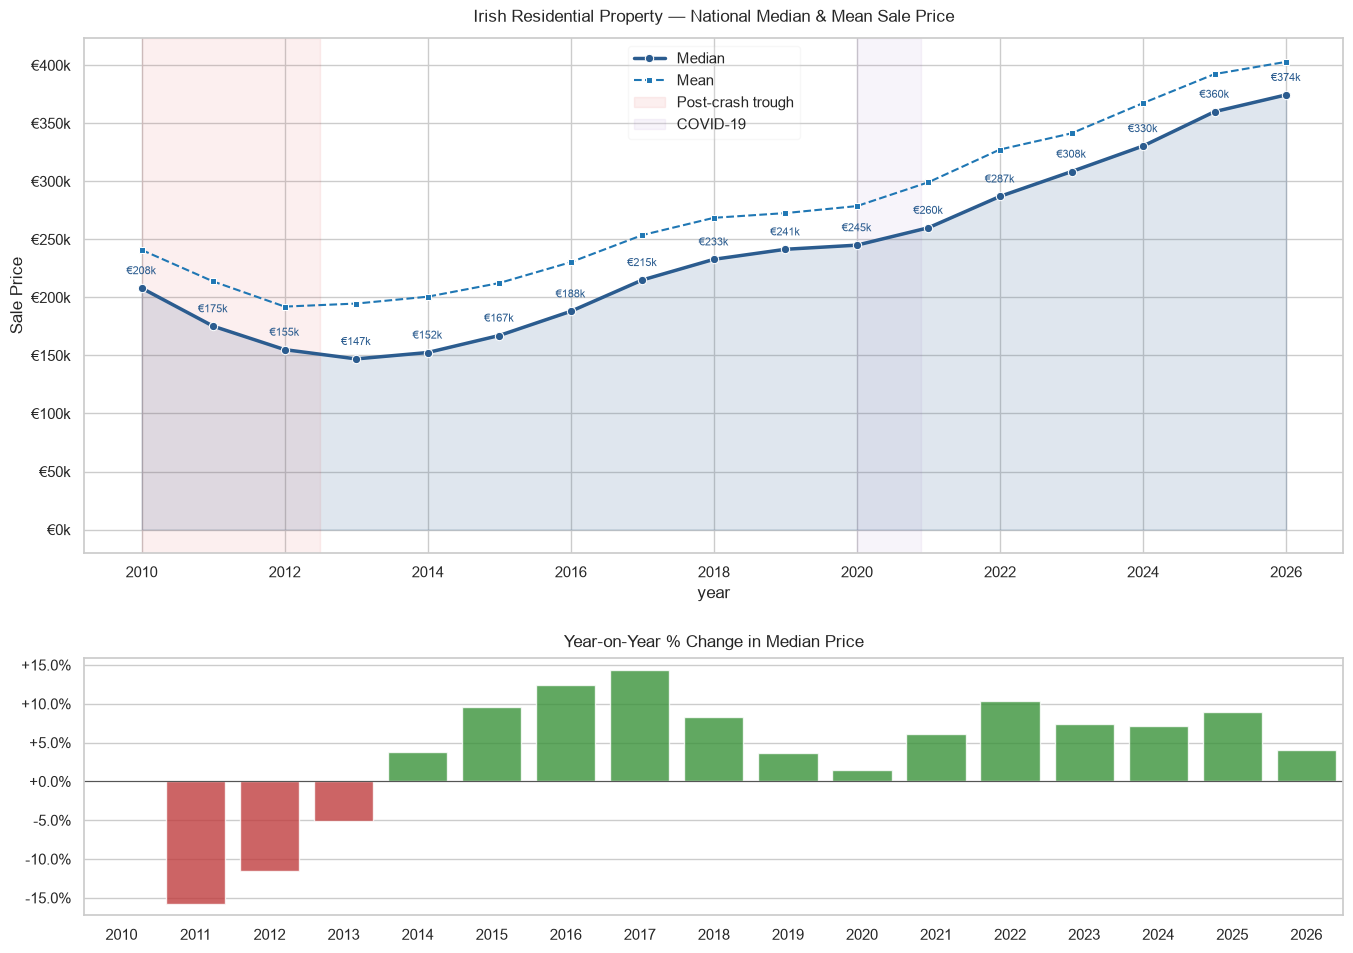

In [14]:


ACCENT = "#2b5c8f"  # Main median line color (e.g., steel blue)
BLUE = "#1f77b4"  # Mean line color
GREEN = "#2ca02c"  # Positive YoY percentage bars
RED = "#d62728"  # Negative YoY percentage bars & post-crash highlight
PURPLE = "#9467bd"  # COVID-19 highlight

sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(
    2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [2, 1]}
)

# --- Top Plot: Price Trends using sns.lineplot ---
ax = axes[0]

# Line plots for Median and Mean
sns.lineplot(
    data=annual,
    x="year",
    y="median_price",
    ax=ax,
    color=ACCENT,
    linewidth=2.5,
    marker="o",
    markersize=6,
    label="Median",
)

sns.lineplot(
    data=annual,
    x="year",
    y="mean_price",
    ax=ax,
    color=BLUE,
    linewidth=1.5,
    linestyle="--",
    marker="s",
    markersize=4,
    label="Mean",
)

# Fill under the line (uses Matplotlib as Seaborn lineplot doesn't have a fill_between parameter)
ax.fill_between(
    annual["year"], annual["median_price"], alpha=0.15, color=ACCENT
)

# Data Point Annotations
for _, row in annual.iterrows():
    ax.annotate(
        f'€{row["median_price"]/1000:.0f}k',
        (row["year"], row["median_price"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8,
        color=ACCENT,
    )

# Highlight Spans
ax.axvspan(2010, 2012.5, alpha=0.07, color=RED, label="Post-crash trough")
ax.axvspan(2020, 2020.9, alpha=0.07, color=PURPLE, label="COVID-19")

ax.set_title(
    "Irish Residential Property — National Median & Mean Sale Price", pad=12
)
ax.set_ylabel("Sale Price")
ax.legend(framealpha=0.15)


# --- Bottom Plot: YoY % Change using sns.barplot ---
ax2 = axes[1]
annual_clean = annual.copy()
annual_clean["yearly_percentage_change"] = annual_clean["yearly_percentage_change"].fillna(0)

# Seaborn barplot allows hue assignment for custom positive/negative colors
sns.barplot(
    data=annual_clean,
    x="year",
    y="yearly_percentage_change",
    hue=annual_clean["yearly_percentage_change"] >= 0,
    palette={True: GREEN, False: RED},
    ax=ax2,
    legend=False,
    alpha=0.8,
)

ax2.axhline(0, color="#555", linewidth=0.8)
ax2.set_title("Year-on-Year % Change in Median Price", pad=8)
ax2.set_xlabel("")
ax2.set_ylabel("")


# --- Formatting Tick Labels directly from Matplotlib values ---
fig.canvas.draw()

# Format Y-Axis Labels
yticks1 = ax.get_yticks()
ax.set_yticklabels([f"€{val/1000:.0f}k" for val in yticks1])

yticks2 = ax2.get_yticks()
ax2.set_yticklabels([f"{val:+.1f}%" for val in yticks2])


plt.tight_layout(pad=2)
plt.savefig(
    "../outputs/images/national_price_trend.png", dpi=150, bbox_inches="tight", facecolor="#0f1117"
)
plt.show()

0     True
1    False
2     True
3    False
4    False
Name: is_dublin, dtype: bool
233825


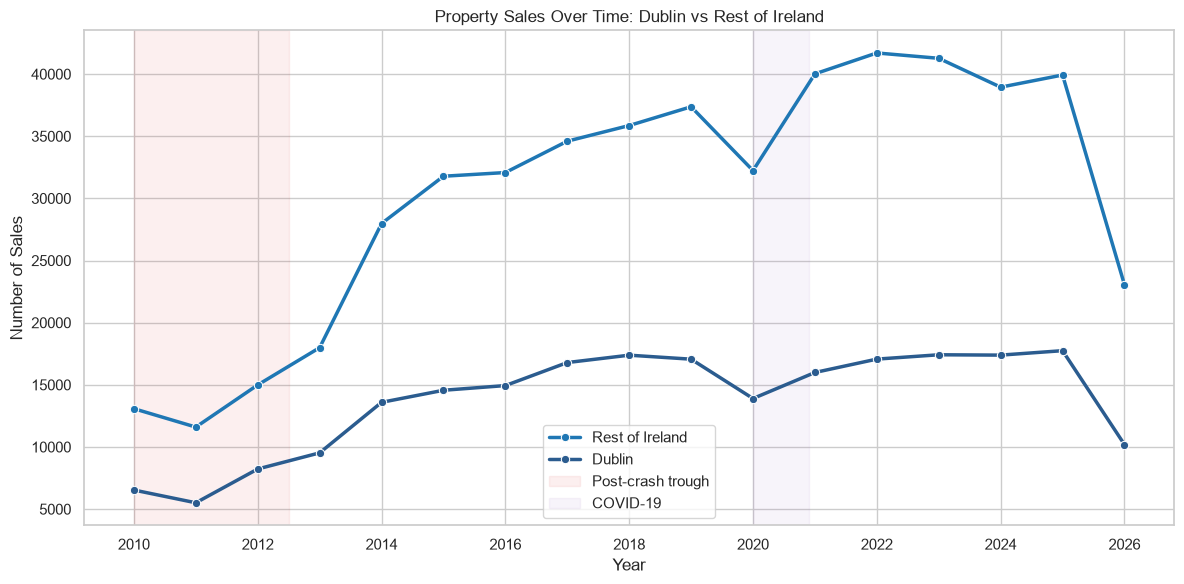

In [15]:
df["is_dublin"] = df["county"] == "dublin"
print(df["is_dublin"].head())
print(df["is_dublin"].sum()) 

yearly_comparison = (
    df.groupby(["year", "is_dublin"])
    .size()
    .reset_index(name="sales_count")
)
yearly_comparison["region"] = yearly_comparison["is_dublin"].map({True: "Dublin", False: "Rest of Ireland"})

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=yearly_comparison,
    x="year",
    y="sales_count",
    hue="region",
    palette={"Dublin": ACCENT, "Rest of Ireland": BLUE},
    linewidth=2.5,
    marker="o",
    markersize=6,
)

# Highlight Spans
plt.axvspan(2010, 2012.5, alpha=0.07, color=RED, label="Post-crash trough")
plt.axvspan(2020, 2020.9, alpha=0.07, color=PURPLE, label="COVID-19")

plt.title("Property Sales Over Time: Dublin vs Rest of Ireland")
plt.ylabel("Number of Sales")
plt.xlabel("Year")
plt.legend(title="")
plt.tight_layout()
plt.savefig("../outputs/images/Property Sales Over time in Dublin vs Rest of Ireland.png")
plt.show()

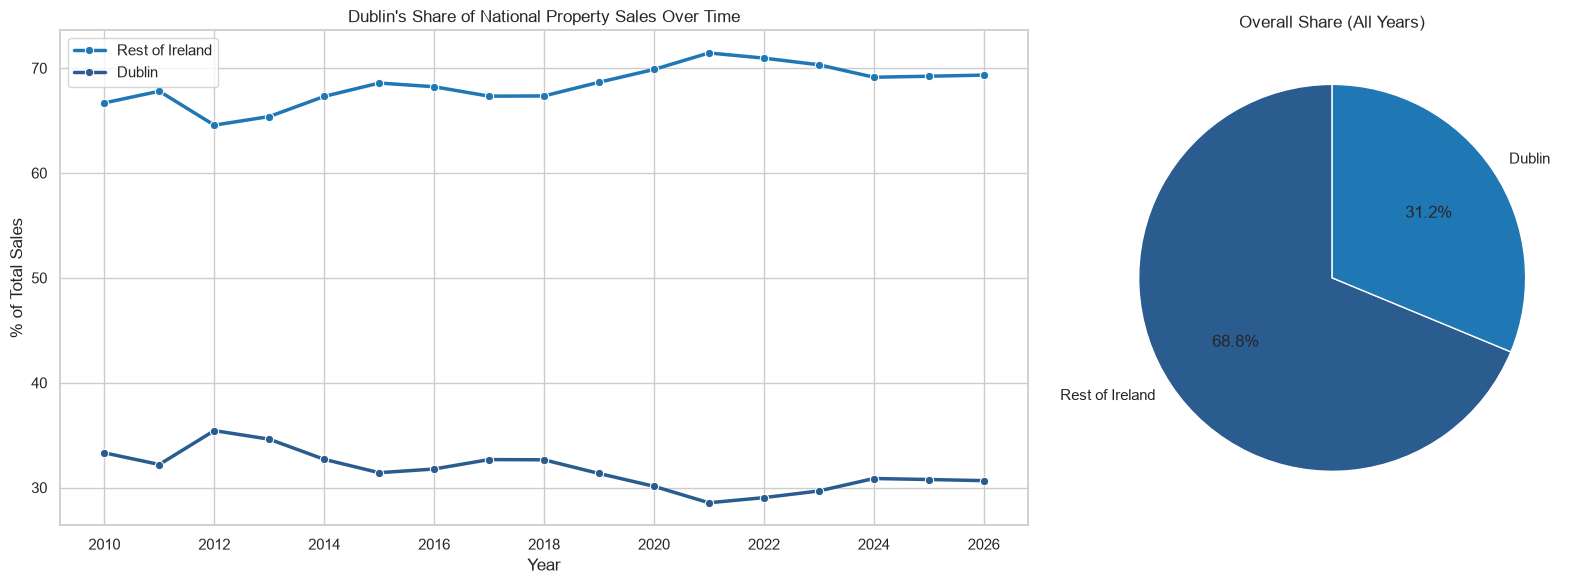

In [16]:
yearly_comparison["total"] = yearly_comparison.groupby("year")["sales_count"].transform("sum")
yearly_comparison["pct_of_total"] = yearly_comparison["sales_count"] / yearly_comparison["total"] * 100

overall_totals = df["is_dublin"].value_counts().rename({True: "Dublin", False: "Rest of Ireland"})

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [2, 1]})

# --- Left: line chart over time ---
sns.lineplot(
    data=yearly_comparison,
    x="year",
    y="pct_of_total",
    hue="region",
    palette={"Dublin": ACCENT, "Rest of Ireland": BLUE},
    linewidth=2.5,
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Dublin's Share of National Property Sales Over Time")
axes[0].set_ylabel("% of Total Sales")
axes[0].set_xlabel("Year")
axes[0].legend(title="")

# --- Right: pie chart, overall total ---
axes[1].pie(
    overall_totals.values,
    labels=overall_totals.index,
    autopct="%1.1f%%",
    colors=[ACCENT, BLUE],
    startangle=90,
)
axes[1].set_title("Overall Share (All Years)")

plt.tight_layout()
plt.savefig("../outputs/images/Dublin_Share_Combined.png")

plt.show()

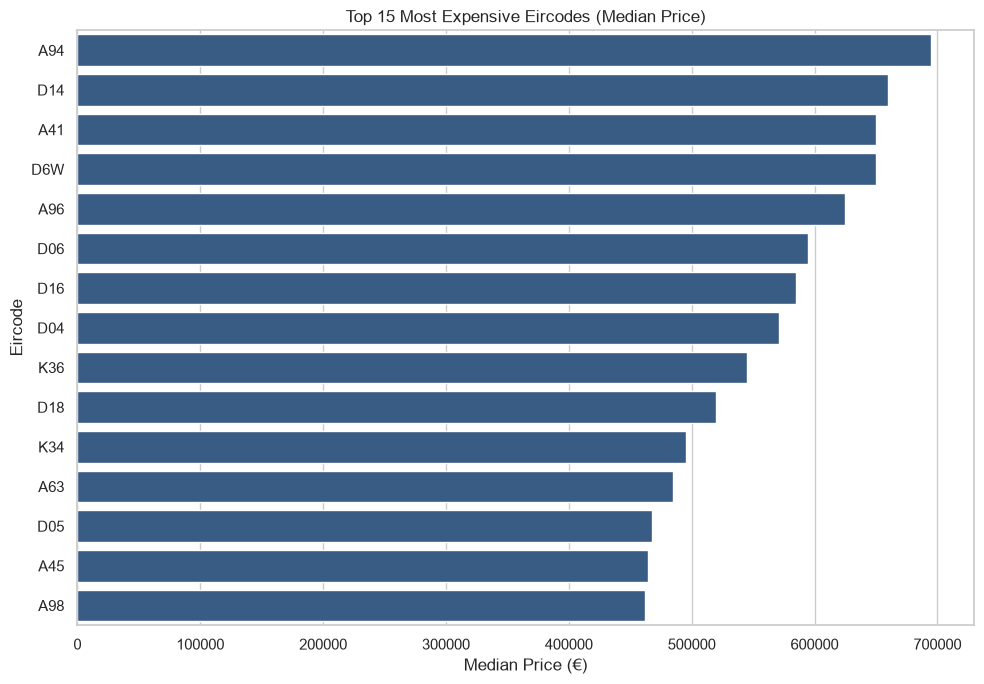

Most expensive eircode: A94 — median €695,000


In [17]:
df["eircode_routing_key"] = df["eircode"].str[:3]

eircode_stats = (
    df.dropna(subset=["eircode_routing_key"])
    .groupby("eircode_routing_key")
    .agg(median_price=("price", "median"), sales_count=("price", "count"))
    .query("sales_count >= 30")  # drop routing keys with too few sales to be meaningful
    .sort_values("median_price", ascending=False)
)

top15 = eircode_stats.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=top15["median_price"], y=top15.index, color=ACCENT)
plt.title("Top 15 Most Expensive Eircodes (Median Price)")
plt.xlabel("Median Price (€)")
plt.ylabel("Eircode")
plt.tight_layout()
plt.savefig("../outputs/images/Most Expensive Eircodes.png")
plt.show()

print(f"Most expensive eircode: {eircode_stats.index[0]} — median €{eircode_stats['median_price'].iloc[0]:,.0f}")

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Check the county data
print(df["county"].head())

# Keep only rows with the information needed for the model
model_df = df.dropna(
    subset=["price", "county", "year", "property_type"]
).copy()

# Cap extreme prices so they don't dominate the regression
lower, upper = model_df["price"].quantile([0.01, 0.99])

model_df = model_df[
    (model_df["price"] >= lower) &
    (model_df["price"] <= upper)
]

# One-hot encode categorical variables
# drop_first=True creates a reference category
X = pd.get_dummies(
    model_df[["county", "year", "property_type"]],
    columns=["county", "property_type"],
    drop_first=True
)

# Target variable
y = model_df["price"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Display model coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient (€)": model.coef_
})

coefficients = (
    coefficients
    .sort_values(by="Coefficient (€)", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 10 features by coefficient:")
print(coefficients.head(10))

# Model performance
print(f"\nR² score: {r2_score(y_test, y_pred):.3f}")
print(
    f"Mean Absolute Error: "
    f"€{mean_absolute_error(y_test, y_pred):,.0f}"
)

0      dublin
1       laois
2      dublin
3       meath
4    kilkenny
Name: county, dtype: str

Top 10 features by coefficient:
                                   Feature  Coefficient (€)
0                            county_dublin    196246.319510
1                           county_wicklow    158491.195068
2                           county_kildare    109137.454744
3                             county_meath     84092.495027
4                              county_cork     69467.273114
5  property_type_Teach/Árasán Cónaithe Nua     61824.344422
6                            county_galway     57759.323468
7                          county_kilkenny     40011.244110
8                             county_louth     28772.704355
9                          county_limerick     20693.567340

R² score: 0.356
Mean Absolute Error: €101,403
